# 01. EDA for Hotel Booking Cancellation Project

Цель ноутбука:
- загрузить и проверить датасет `hotel_bookings.csv`;
- изучить целевую переменную `is_canceled`;
- посмотреть на распределения и ключевые признаки;
- сформулировать выводы для отчета и выбора моделей.

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)

DATA_PATH = Path("..") / "data" / "hotel_bookings.csv"

In [11]:
df = pd.read_csv(DATA_PATH)
df.head()

C:\Users\onini\AppData\Local\Temp\ipykernel_1268\2006162025.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NULL,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 1. Общая информация о данных

In [12]:
print(f"Shape: {df.shape}")
print("\nDtypes:")
display(df.dtypes)

print("\nMissing values:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

Shape: (119390, 32)

Dtypes:


hotel                               object
 is_canceled                         int64
 lead_time                           int64
 arrival_date_year                   int64
 arrival_date_month                 object
 arrival_date_week_number            int64
 arrival_date_day_of_month           int64
 stays_in_weekend_nights             int64
 stays_in_week_nights                int64
 adults                              int64
 children                           object
 babies                              int64
 meal                               object
 country                            object
 market_segment                     object
 distribution_channel               object
 is_repeated_guest                   int64
 previous_cancellations              int64
 previous_bookings_not_canceled      int64
 reserved_room_type                 object
 assigned_room_type                 object
 booking_changes                     int64
 deposit_type                       object
 agent     


Missing values:


Series([], dtype: int64)

In [13]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "nunique": df.nunique(dropna=False),
})
summary.sort_values("missing", ascending=False).head(15)

,dtype,missing,missing_pct,nunique
hotel,object,0,0.0,2
is_canceled,int64,0,0.0,2
lead_time,int64,0,0.0,479
arrival_date_year,int64,0,0.0,3
arrival_date_month,object,0,0.0,12
arrival_date_week_number,int64,0,0.0,53
arrival_date_day_of_month,int64,0,0.0,31
stays_in_weekend_nights,int64,0,0.0,17
stays_in_week_nights,int64,0,0.0,35
adults,int64,0,0.0,14


## 2. Целевая переменная

,count,pct
is_canceled,,
0,75166,62.96
1,44224,37.04


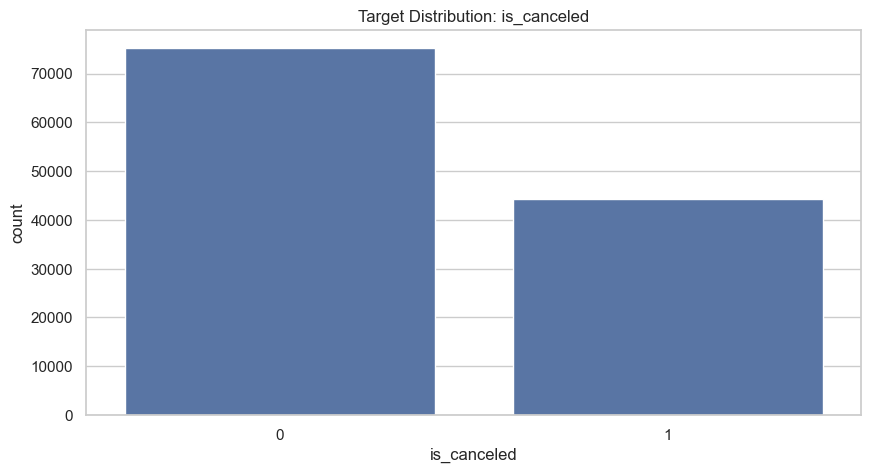

In [14]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace("\ufeff", "", regex=False)
target_dist = df["is_canceled"].value_counts().sort_index()
target_pct = (df["is_canceled"].value_counts(normalize=True).sort_index() * 100).round(2)

display(pd.DataFrame({"count": target_dist, "pct": target_pct}))

sns.countplot(data=df, x="is_canceled")
plt.title("Target Distribution: is_canceled")
plt.xlabel("is_canceled")
plt.ylabel("count")
plt.show()

## 3. Легкая очистка для EDA

In [15]:
eda_df = df.copy()
eda_df["children"] = eda_df["children"].fillna(0)
eda_df["agent_missing"] = eda_df["agent"].isna().astype(int)
eda_df["company_missing"] = eda_df["company"].isna().astype(int)

eda_df[["children", "agent_missing", "company_missing"]].head()

,children,agent_missing,company_missing
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0


## 4. Числовые признаки и отмены

In [16]:
numeric_features = [
    "lead_time",
    "adr",
    "adults",
    "children",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "total_of_special_requests",
    "stays_in_week_nights",
    "stays_in_weekend_nights",
]

eda_df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
adr,119390.0,101.831122,50.535790,-6.38,69.29,94.575,126.0,5400.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
previous_cancellations,119390.0,0.087118,0.844336,0.00,0.00,0.000,0.0,26.0
previous_bookings_not_canceled,119390.0,0.137097,1.497437,0.00,0.00,0.000,0.0,72.0
booking_changes,119390.0,0.221124,0.652306,0.00,0.00,0.000,0.0,21.0
days_in_waiting_list,119390.0,2.321149,17.594721,0.00,0.00,0.000,0.0,391.0
total_of_special_requests,119390.0,0.571363,0.792798,0.00,0.00,0.000,1.0,5.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0


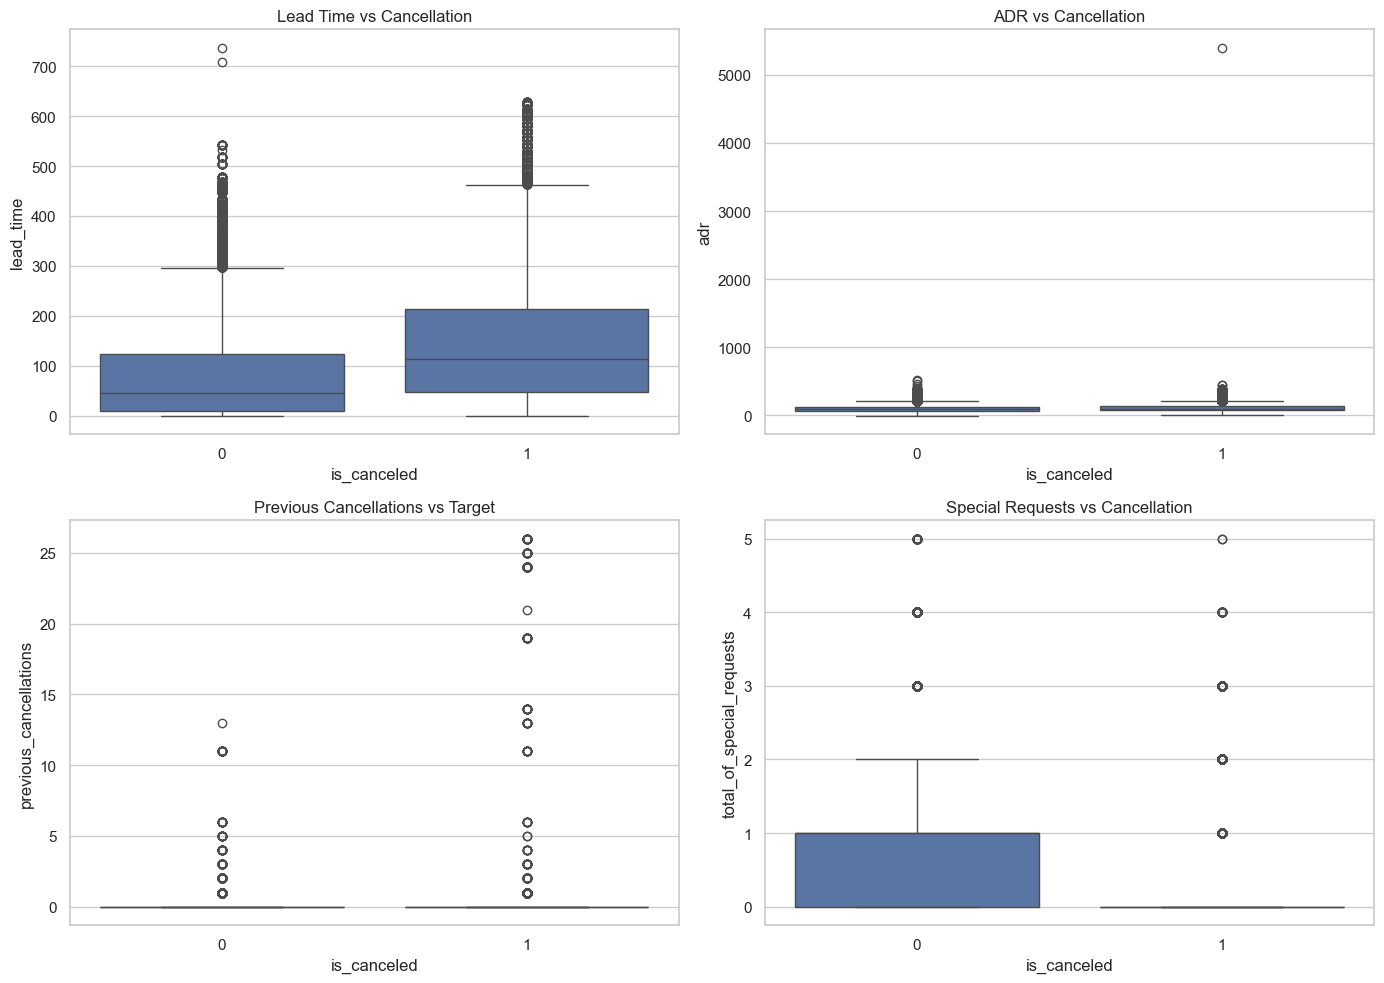

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=eda_df, x="is_canceled", y="lead_time", ax=axes[0, 0])
axes[0, 0].set_title("Lead Time vs Cancellation")

sns.boxplot(data=eda_df, x="is_canceled", y="adr", ax=axes[0, 1])
axes[0, 1].set_title("ADR vs Cancellation")

sns.boxplot(data=eda_df, x="is_canceled", y="previous_cancellations", ax=axes[1, 0])
axes[1, 0].set_title("Previous Cancellations vs Target")

sns.boxplot(data=eda_df, x="is_canceled", y="total_of_special_requests", ax=axes[1, 1])
axes[1, 1].set_title("Special Requests vs Cancellation")

plt.tight_layout()
plt.show()

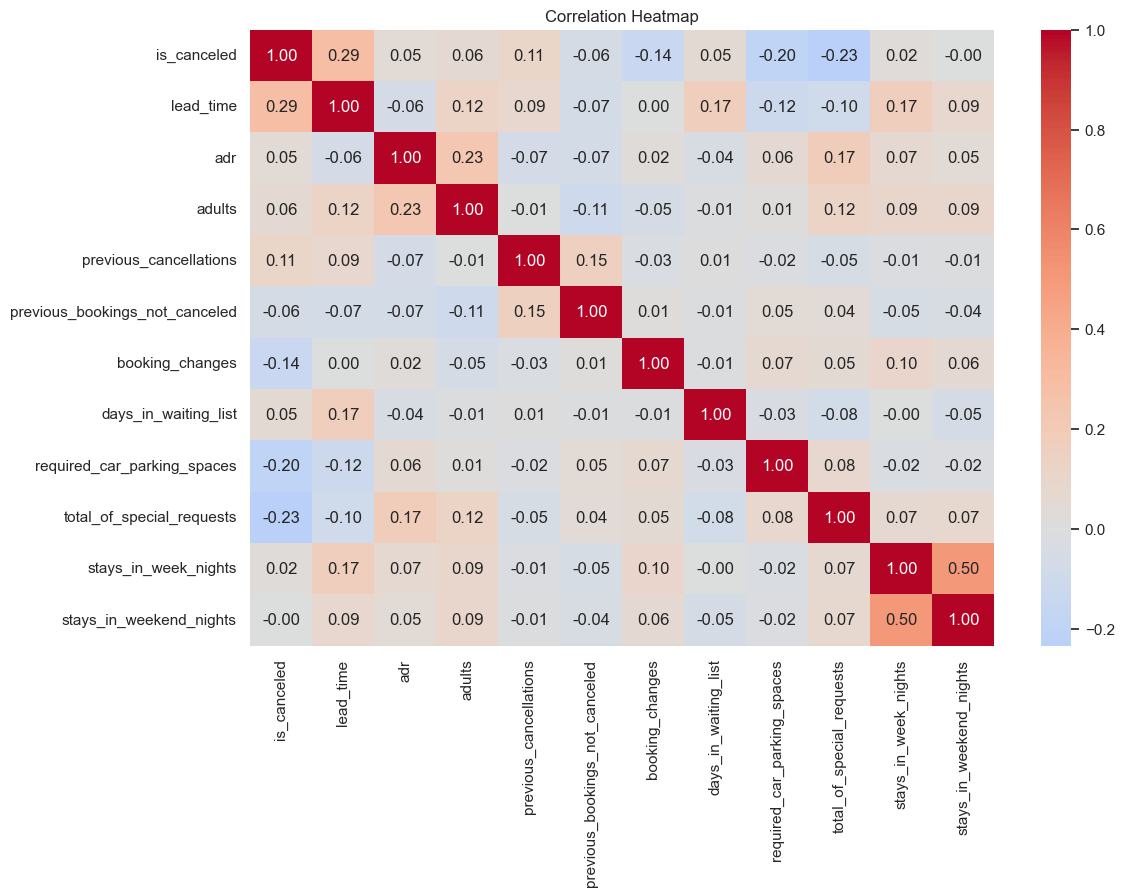

In [18]:
corr_features = [
    "is_canceled",
    "lead_time",
    "adr",
    "adults",
    "children",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "stays_in_week_nights",
    "stays_in_weekend_nights",
]

corr = eda_df[corr_features].corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## 5. Категориальные признаки

In [19]:
categorical_features = [
    "hotel",
    "meal",
    "market_segment",
    "distribution_channel",
    "deposit_type",
    "customer_type",
    "reserved_room_type",
]

for col in categorical_features:
    display(
        pd.crosstab(eda_df[col], eda_df["is_canceled"], normalize="index")
        .rename(columns={0: "not_canceled", 1: "canceled"})
        .sort_values("canceled", ascending=False)
        .head(10)
    )

is_canceled,not_canceled,canceled
hotel,,
City Hotel,0.582730,0.417270
Resort Hotel,0.722366,0.277634


is_canceled,not_canceled,canceled
meal,,
FB,0.401003,0.598997
BB,0.626151,0.373849
SC,0.627606,0.372394
HB,0.655397,0.344603
Undefined,0.755346,0.244654


is_canceled,not_canceled,canceled
market_segment,,
Undefined,0.000000,1.000000
Groups,0.389380,0.610620
Online TA,0.632789,0.367211
Offline TA/TO,0.656840,0.343160
Aviation,0.780591,0.219409
Corporate,0.812653,0.187347
Direct,0.846581,0.153419
Complementary,0.869448,0.130552


is_canceled,not_canceled,canceled
distribution_channel,,
Undefined,0.200000,0.800000
TA/TO,0.589741,0.410259
Corporate,0.779242,0.220758
GDS,0.808290,0.191710
Direct,0.825401,0.174599


is_canceled,not_canceled,canceled
deposit_type,,
Non Refund,0.006376,0.993624
No Deposit,0.716230,0.283770
Refundable,0.777778,0.222222


is_canceled,not_canceled,canceled
customer_type,,
Transient,0.592537,0.407463
Contract,0.690383,0.309617
Transient-Party,0.745701,0.254299
Group,0.897747,0.102253


is_canceled,not_canceled,canceled
reserved_room_type,,
P,0.000000,1.000000
H,0.592346,0.407654
A,0.608926,0.391074
G,0.635626,0.364374
L,0.666667,0.333333
C,0.669528,0.330472
B,0.670841,0.329159
D,0.682204,0.317796
F,0.696237,0.303763


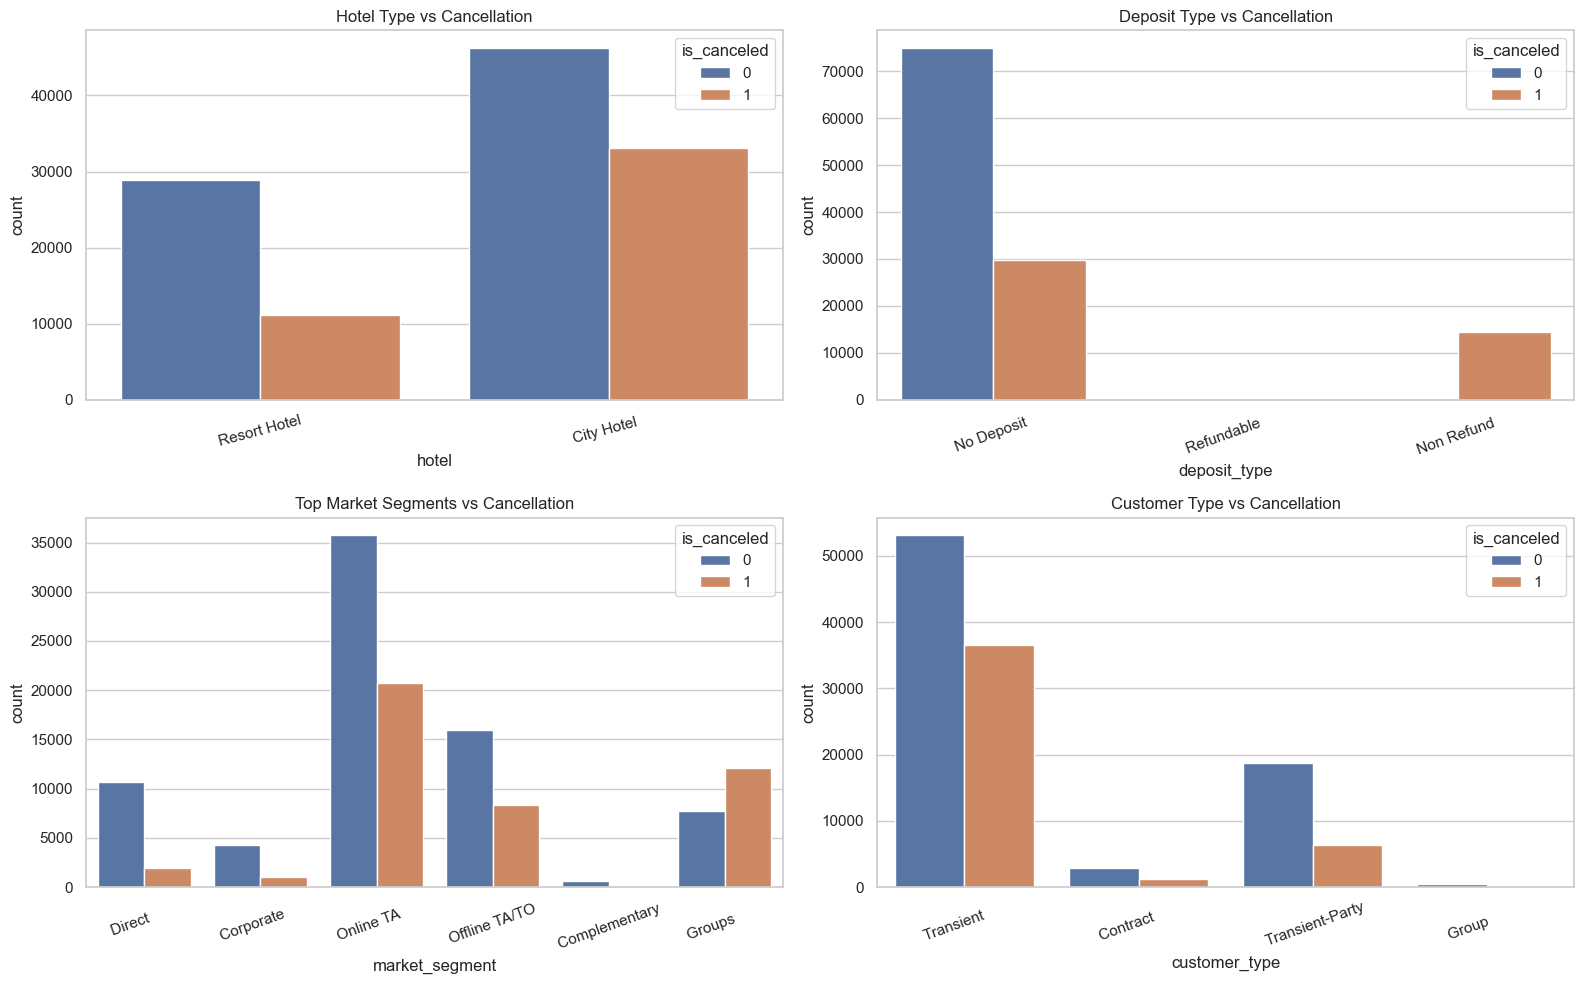

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.countplot(data=eda_df, x="hotel", hue="is_canceled", ax=axes[0, 0])
axes[0, 0].set_title("Hotel Type vs Cancellation")
axes[0, 0].tick_params(axis="x", rotation=15)

sns.countplot(data=eda_df, x="deposit_type", hue="is_canceled", ax=axes[0, 1])
axes[0, 1].set_title("Deposit Type vs Cancellation")
axes[0, 1].tick_params(axis="x", rotation=20)

top_segments = eda_df["market_segment"].value_counts().head(6).index
sns.countplot(data=eda_df[eda_df["market_segment"].isin(top_segments)], x="market_segment", hue="is_canceled", ax=axes[1, 0])
axes[1, 0].set_title("Top Market Segments vs Cancellation")
axes[1, 0].tick_params(axis="x", rotation=20)

sns.countplot(data=eda_df, x="customer_type", hue="is_canceled", ax=axes[1, 1])
axes[1, 1].set_title("Customer Type vs Cancellation")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 6. Временные и сезонные аспекты

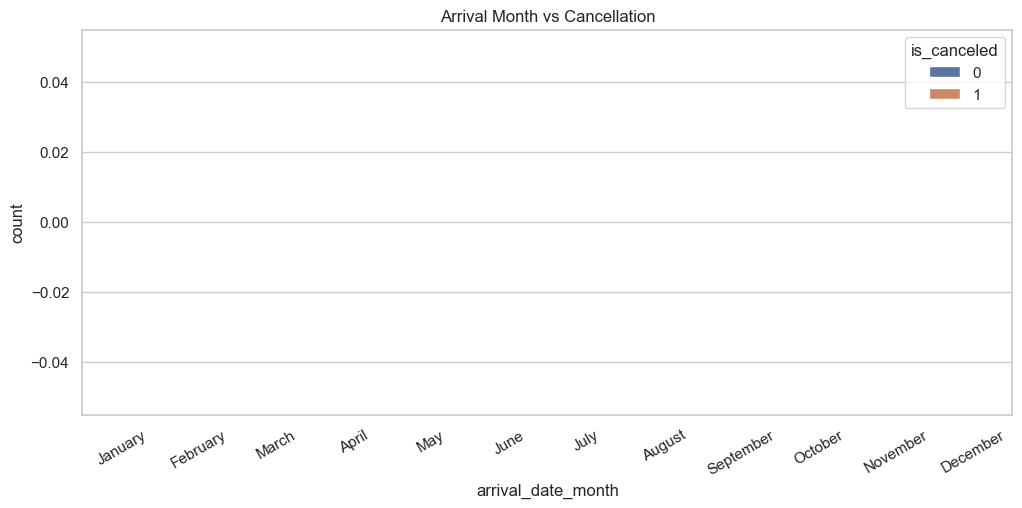

In [21]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

plt.figure(figsize=(12, 5))
sns.countplot(data=eda_df, x="arrival_date_month", hue="is_canceled", order=month_order)
plt.title("Arrival Month vs Cancellation")
plt.xticks(rotation=30)
plt.show()

In [22]:
monthly_cancel_rate = (
    pd.crosstab(eda_df["arrival_date_month"], eda_df["is_canceled"], normalize="index")
    .rename(columns={0: "not_canceled", 1: "canceled"})
    .reindex(month_order)
)
monthly_cancel_rate

is_canceled,not_canceled,canceled
arrival_date_month,,
January,NaN,NaN
February,NaN,NaN
March,NaN,NaN
April,NaN,NaN
May,NaN,NaN
June,NaN,NaN
July,NaN,NaN
August,NaN,NaN
September,NaN,NaN


## 7. Подготовка выводов для отчета

In [23]:
insights = {
    "rows": int(eda_df.shape[0]),
    "cols": int(eda_df.shape[1]),
    "cancel_rate_pct": round(float(eda_df["is_canceled"].mean() * 100), 2),
    "lead_time_mean_canceled": round(float(eda_df.loc[eda_df["is_canceled"] == 1, "lead_time"].mean()), 2),
    "lead_time_mean_not_canceled": round(float(eda_df.loc[eda_df["is_canceled"] == 0, "lead_time"].mean()), 2),
    "special_requests_mean_canceled": round(float(eda_df.loc[eda_df["is_canceled"] == 1, "total_of_special_requests"].mean()), 2),
    "special_requests_mean_not_canceled": round(float(eda_df.loc[eda_df["is_canceled"] == 0, "total_of_special_requests"].mean()), 2),
}
insights

{'rows': 119390,
 'cols': 34,
 'cancel_rate_pct': 37.04,
 'lead_time_mean_canceled': 144.85,
 'lead_time_mean_not_canceled': 79.98,
 'special_requests_mean_canceled': 0.33,
 'special_requests_mean_not_canceled': 0.71}

## 8. Основные выводы

Пример формулировок для отчета:

1. В датасете есть заметная доля отмен, поэтому задача бинарной классификации практически осмысленна.
2. Признак `lead_time` выглядит одним из самых сильных кандидатов: длинные бронирования заранее чаще отменяются.
3. История прошлых отмен и тип депозита явно связаны с целевой переменной.
4. У клиентов без отмен чаще больше специальных запросов и более стабильное поведение.
5. Есть выраженные различия между сегментами бронирования и типами клиентов, значит one-hot кодирование категорий оправдано.
6. Для baseline достаточно логистической регрессии, но нелинейные модели и MLP логично проверить как более сильные кандидаты.